In [1]:
import PIL
import matplotlib.pyplot as plt
import torch
import torchvision
import clearml
import os

from PIL import Image
from torchvision.transforms import ToTensor, Compose, RandomRotation, GaussianBlur, RandomHorizontalFlip, RandomChoice
from clearml import Dataset, Task
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights

In [2]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ZS6BVHQGC1N89QELVVW3EITSJBRKZS
%env CLEARML_API_SECRET_KEY=OmTm8v5yFGP17jRh0wzamCJQKfmL_0e-VPYo4vE4eG-6XIzs5Aa89UvDmQ4F9nOklBQ

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ZS6BVHQGC1N89QELVVW3EITSJBRKZS
env: CLEARML_API_SECRET_KEY=OmTm8v5yFGP17jRh0wzamCJQKfmL_0e-VPYo4vE4eG-6XIzs5Aa89UvDmQ4F9nOklBQ


# Exploratory Data Analysis

In [13]:
!unzip -q Brain_MRI_Classification.zip

In [ ]:
!unzip -q Brain_MRI_Segmentation.zip

In [13]:
# Upload the Brain MRI Classification dataset
dataset = Dataset.create(dataset_name="Brain_MRI_Classification", dataset_project="NeuroVision")
dataset.add_files(path=r"/content/Brain_MRI_Classification")
dataset.upload()
dataset.finalize()

# Upload the Brain MRI Segmentation dataset
dataset = Dataset.create(dataset_name="Brain_MRI_Segmentation", dataset_project="NeuroVision")
dataset.add_files(path=r"/content/Brain_MRI_Segmentation")
dataset.upload()
dataset.finalize()

ClearML results page: https://app.clear.ml/projects/958042f4711844288e4901ae91b854fc/experiments/032676ed8c8f4f38ba36b57ea35666b7/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/958042f4711844288e4901ae91b854fc/experiments/032676ed8c8f4f38ba36b57ea35666b7
Generating SHA2 hash for 3264 files


100%|██████████| 3264/3264 [00:00<00:00, 7596.35it/s]


Hash generation completed
Uploading dataset changes (3264 files compressed to 87.99 MiB) to https://files.clear.ml


███████████████████████████████ 100% | 87.99/87.99 MB [00:01<00:00, 44.02MB/s]: 


File compression and upload completed: total size 87.99 MiB, 1 chunk(s) stored (average size 87.99 MiB)
ClearML results page: https://app.clear.ml/projects/78587f13982548fe8187acb7422b19a9/experiments/7720aa8ea7084d89b4b1b3fbc24af1ca/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/78587f13982548fe8187acb7422b19a9/experiments/7720aa8ea7084d89b4b1b3fbc24af1ca
Generating SHA2 hash for 2149 files


100%|██████████| 2149/2149 [00:00<00:00, 6639.00it/s]


Hash generation completed
Uploading dataset changes (2149 files compressed to 85.24 MiB) to https://files.clear.ml


███████████████████████████████ 100% | 85.24/85.24 MB [00:01<00:00, 43.47MB/s]: 


File compression and upload completed: total size 85.24 MiB, 1 chunk(s) stored (average size 85.24 MiB)


True

In [3]:
def split_distribution(dataset_path: str) -> tuple:
  '''
  Plots the distribution of the different dataset splits, i.e. train, val, test
  Returns the figure object of the plot as well as the distribution of each class
  in the training set (if possible)
  '''

  split_distr = {}
  class_distr = {}
  splits = os.listdir(dataset_path)

  for split in splits:
    split_path = os.path.join(dataset_path, split)
    split_distr[split] = 0

    if len(splits) == 2: # The classification dataset
      for class_label in os.listdir(split_path):
        class_path = os.path.join(split_path, class_label)
        n_samples = len(os.listdir(class_path))
        split_distr[split] += n_samples

        if split == "Training":
          class_distr[class_label] = n_samples
    else: # The segmentation dataset
      split_distr[split] += len(os.listdir(split_path))

  fig, ax = plt.subplots()
  bar = ax.bar(split_distr.keys(), split_distr.values(), color='g', alpha=0.6)
  ax.bar_label(bar, labels=split_distr.values())
  ax.set_ylim(top=max(split_distr.values()) + 300)
  ax.set_title("Split Distribution")
  ax.set_xlabel("Number of samples")
  ax.set_ylabel("Split")
  plt.show()

  return (fig, class_distr)

def class_distribution(class_distr: dict):
  fig, ax = plt.subplots(figsize=(10, 5))
  bar = ax.bar(class_distr.keys(), class_distr.values(), color='orange', alpha=0.6)
  ax.bar_label(bar, class_distr.values())
  ax.set_title("Class Distribution")
  ax.set_xlabel("Class")
  ax.set_ylabel("Number of samples")
  plt.show()

  return fig

## Classification Dataset

In [4]:
dataset = Dataset.get(dataset_id="484ab22d3dc64d518699eb07e6288822")
classification_local_copy = dataset.get_local_copy()
classification_local_copy

'/root/.clearml/cache/storage_manager/datasets/ds_484ab22d3dc64d518699eb07e6288822'

In [9]:
task = Task.init(project_name="NeuroVision", task_name="EDA",
                 task_type=Task.TaskTypes.data_processing,
                 auto_connect_frameworks={"matplotlib": False})

logger = task.get_logger()

ClearML Task: created new task id=de85db3b986045c2bf2447c7b182815d
ClearML results page: https://app.clear.ml/projects/152174e25bf042ceb628c711c47a93c5/experiments/de85db3b986045c2bf2447c7b182815d/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


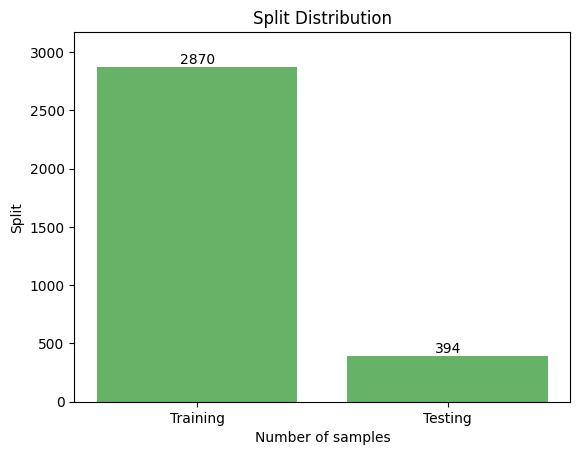

In [5]:
class_split_distr, class_distr = split_distribution(classification_local_copy)

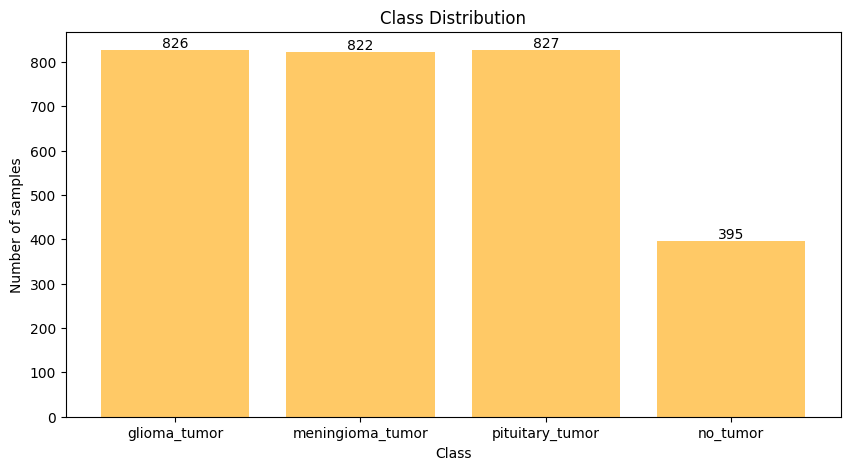

In [6]:
class_distr = class_distribution(class_distr)

# Segmentation Dataset

In [7]:
dataset = Dataset.get(dataset_id="1702b04f4c89430a854ed7fc9e51f84e")
segmentation_local_copy = dataset.get_local_copy()
segmentation_local_copy

'/root/.clearml/cache/storage_manager/datasets/ds_1702b04f4c89430a854ed7fc9e51f84e'

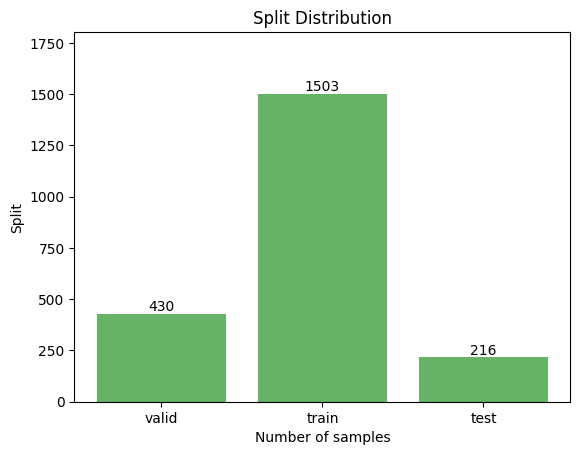

In [8]:
seg_split_distr, _ = split_distribution(segmentation_local_copy)

In [14]:
logger.report_matplotlib_figure(title="Distribution", series="Class_Split", figure=class_split_distr)
logger.report_matplotlib_figure(title="Distribution", series="Seg_Split", figure=seg_split_distr)
logger.report_matplotlib_figure(title="Distribution", series="Class", figure=class_distr)

task.close()

/usr/local/lib/python3.12/dist-packages/clearml/utilities/plotlympl/renderer.py:209: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



# Data Preprocessing

In [9]:
augmentation = Compose([RandomChoice(transforms=[RandomRotation(180),
                                                 RandomHorizontalFlip(p=1),
                                                 GaussianBlur(kernel_size=19)])])

In [11]:
dataset_path = os.path.join(classification_local_copy, "Training")
os.mkdir("Augmented_Data")

for class_label in os.listdir(dataset_path):
  class_path = os.path.join(dataset_path, class_label)

  # Make directory if it does not exist
  if not os.path.exists(f"Augmented_Data/{class_label}"):
    current_save_path = f"Augmented_Data/{class_label}"
    os.mkdir(current_save_path)

  for img in os.listdir(class_path):
    image_path = os.path.join(class_path, img)
    image = Image.open(image_path)

    # Perform data augmentation and save
    augmented_image = augmentation(image)
    augmented_image.save(f"{current_save_path}/{img}_augmented.jpg")

In [14]:
# Upload the Augmented Dataset
dataset = Dataset.create(dataset_name="Brain_MRI_Classification",
                         dataset_project="NeuroVision",
                         parent_datasets=["032676ed8c8f4f38ba36b57ea35666b7"])

dataset.add_files(path=r"/content/Augmented_Data")
dataset.upload()
dataset.finalize()

ClearML results page: https://app.clear.ml/projects/958042f4711844288e4901ae91b854fc/experiments/0d1536de1bba412795756503de318a76/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/958042f4711844288e4901ae91b854fc/experiments/0d1536de1bba412795756503de318a76
Generating SHA2 hash for 2870 files


100%|██████████| 2870/2870 [00:00<00:00, 10233.04it/s]


Hash generation completed
Uploading dataset changes (2870 files compressed to 57.02 MiB) to https://files.clear.ml


███████████████████████████████ 100% | 57.02/57.02 MB [00:01<00:00, 40.54MB/s]: 


File compression and upload completed: total size 57.02 MiB, 1 chunk(s) stored (average size 57.02 MiB)


True